# Lab Experiment 8: Play Tennis Classification

Amogh Sahore<br>
2547108

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

## 2. Load and Explore the Dataset

In [2]:
data_candidates = [
    Path('Lab 8 - Sheet1.csv'),
    Path('LAB08') / 'Lab 8 - Sheet1.csv',
    Path('..') / 'LAB08' / 'Lab 8 - Sheet1.csv',
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Lab 8 - Sheet1.csv was not found')

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print('Dataset shape:', df.shape)
duplicate_rows = df.duplicated(
    subset=['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis']
).sum()

print('Missing values:', df.isna().sum().sum())
print('Repeated weather/target rows:', duplicate_rows)
display(df.head())
display(df['Play Tennis'].value_counts().rename_axis('Play Tennis').reset_index(name='Count'))

Dataset shape: (50, 6)
Missing values: 0
Repeated weather/target rows: 14


,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


,Play Tennis,Count
0,Yes,34
1,No,16


**Observation:** Outlook, Temperature, Humidity, and Wind are the predictors. The `No` column is only a serial number. The dataset also contains 14 repeated weather/target rows, so a small random test split may give optimistic results.

## 3. Separate Features and Target, Then Split the Data

In [3]:
target_column = 'Play Tennis'
feature_columns = ['Outlook', 'Temperature', 'Humidity', 'Wind']

X = df[feature_columns].copy()
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[target_column])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Feature columns:', feature_columns)
print('Target classes:', list(target_encoder.classes_))
print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Feature columns: ['Outlook', 'Temperature', 'Humidity', 'Wind']
Target classes: ['No', 'Yes']
Training set shape: (40, 4)
Testing set shape: (10, 4)


The data is split 80:20. Stratification preserves the class ratio and `random_state=42` makes the result reproducible.

## 4. Encode Categorical Values for Categorical Naive Bayes

In [4]:
# CategoricalNB requires each categorical feature to be represented by
# non-negative integer category codes. The encoder is fitted on training data only.
category_encoder = OrdinalEncoder()
X_train_nb = category_encoder.fit_transform(X_train).astype(int)
X_test_nb = category_encoder.transform(X_test).astype(int)

encoded_training_preview = pd.DataFrame(X_train_nb, columns=feature_columns)
display(encoded_training_preview.head())
print('Category order learned for each feature:')
for feature, categories in zip(feature_columns, category_encoder.categories_):
    print(f'{feature}: {list(categories)}')

,Outlook,Temperature,Humidity,Wind
0,2,0,0,1
1,2,1,0,1
2,0,1,0,1
3,0,2,1,0
4,2,2,0,0


Category order learned for each feature:
Outlook: ['Overcast', 'Rain', 'Sunny']
Temperature: ['Cool', 'Hot', 'Mild']
Humidity: ['High', 'Normal']
Wind: ['Strong', 'Weak']


Ordinal encoding is appropriate here because Categorical Naive Bayes models category counts, not numerical distance or magnitude. The numeric codes are only labels for categories.

## 5. Train and Evaluate Categorical Naive Bayes

In [5]:
categorical_nb = CategoricalNB(alpha=1.0)
categorical_nb.fit(X_train_nb, y_train)
nb_predictions = categorical_nb.predict(X_test_nb)

nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f'Categorical Naive Bayes accuracy: {nb_accuracy:.4f}')

print('Classification report:')
print(classification_report(
    y_test, nb_predictions, target_names=target_encoder.classes_, zero_division=0
))

Categorical Naive Bayes accuracy: 0.9000
Classification report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



,Predicted No,Predicted Yes
Actual No,2,1
Actual Yes,0,7


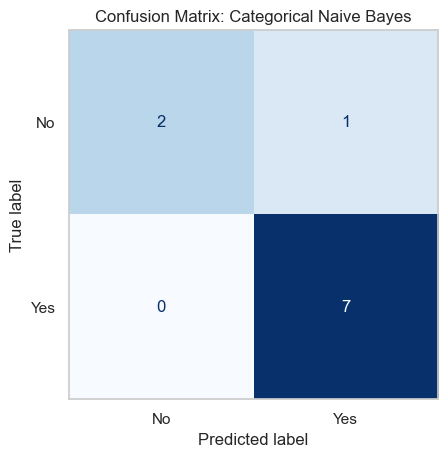

In [6]:
nb_confusion = confusion_matrix(y_test, nb_predictions)
display(pd.DataFrame(
    nb_confusion, index=[f'Actual {name}' for name in target_encoder.classes_],
    columns=[f'Predicted {name}' for name in target_encoder.classes_]
))

ConfusionMatrixDisplay(
    confusion_matrix=nb_confusion, display_labels=target_encoder.classes_
).plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix: Categorical Naive Bayes')
plt.grid(False)
plt.show()

Categorical Naive Bayes applies Bayes' theorem. It estimates the probability of each target class from the feature-category frequencies and assumes features are conditionally independent given the class. The smoothing value `alpha=1.0` prevents zero probabilities for category combinations not seen during training.

## 6. Predict the Required Weather Condition

In [7]:
new_weather = pd.DataFrame([
    {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}
])

new_weather_nb = category_encoder.transform(new_weather).astype(int)
predicted_code = categorical_nb.predict(new_weather_nb)
predicted_class = target_encoder.inverse_transform(predicted_code)[0]
class_probabilities = categorical_nb.predict_proba(new_weather_nb)[0]

print('Weather condition:')
display(new_weather)
print(f'Predicted class: {predicted_class}')
print('Class probabilities:')
display(pd.DataFrame({
    'Class': target_encoder.classes_,
    'Probability': class_probabilities
}).assign(Probability=lambda result: result['Probability'].round(4)))

Weather condition:


,Outlook,Temperature,Humidity,Wind
0,Sunny,Cool,High,Strong


Predicted class: No
Class probabilities:


,Class,Probability
0,No,0.7894
1,Yes,0.2106


## 7. Compare with Decision Tree and Logistic Regression

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
1,Decision Tree,1.0,1.0000,1.0,1.0000
0,Categorical Naive Bayes,0.9,0.9125,0.9,0.8933
2,Logistic Regression,0.9,0.9125,0.9,0.8933


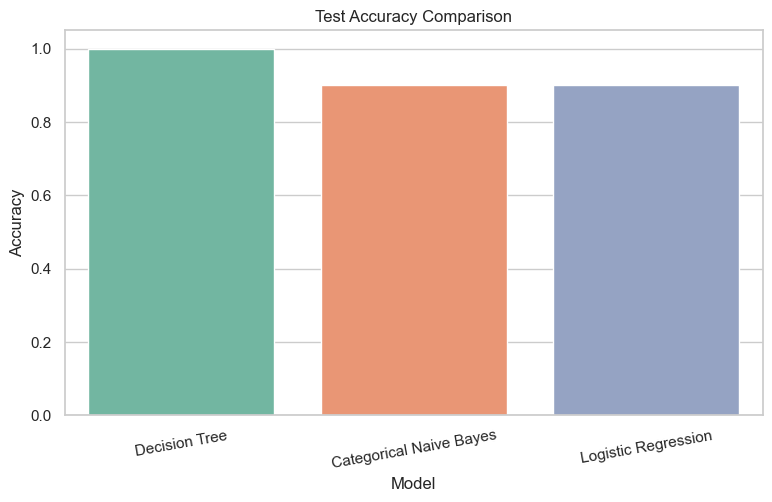

In [8]:
# One-hot encoding is used for these two models so every category is represented
# without implying an artificial order between values such as Sunny and Rain.
one_hot = ColumnTransformer(
    transformers=[('categorical', OneHotEncoder(handle_unknown='ignore'), feature_columns)],
    remainder='drop'
)

decision_tree = Pipeline([
    ('encoding', one_hot),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

logistic_regression = Pipeline([
    ('encoding', one_hot),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

models = {
    'Categorical Naive Bayes': (categorical_nb, X_train_nb, X_test_nb),
    'Decision Tree': (decision_tree, X_train, X_test),
    'Logistic Regression': (logistic_regression, X_train, X_test)
}

comparison_rows = []
for model_name, (model, train_data, test_data) in models.items():
    if model_name != 'Categorical Naive Bayes':
        model.fit(train_data, y_train)
    predictions = model.predict(test_data)
    comparison_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision (weighted)': precision_score(y_test, predictions, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_test, predictions, average='weighted', zero_division=0),
        'F1 Score (weighted)': f1_score(y_test, predictions, average='weighted', zero_division=0)
    })

comparison = pd.DataFrame(comparison_rows).sort_values('Accuracy', ascending=False)
display(comparison.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x='Model', y='Accuracy', hue='Model', legend=False, palette='Set2')
plt.ylim(0, 1.05)
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=10)
plt.show()

## Conclusion

Categorical Naive Bayes achieved 90% accuracy and predicted `No` for Sunny/Cool/High/Strong. Decision Tree achieved 100%, while Logistic Regression achieved 90%. Since the test set has only 10 rows and the dataset contains repeated combinations, these results should be treated as specific to this split.